# ERP analysis using MNE

> A serious attempt at all the assignments is mandatory to grant access to the final exam. Refer to the course manual for more details (section *Overview* on Brightspace). 

> Please add today's topic to your knowledge graph.

**Learning goals:**
- Get familiar with the MNE toolbox for EEG analysis;
- Get familiar with sklearn for EEG decoding;
- Understand ERPs and their sptial and temporal components; 
- Understand temporal, spatial, and spatio-temporal decoding;
- Understand significance testing using the permutation test.

**Solutions file:**

For this assignment, a solutions file will be released after the deadline.


## Top-down view onto this notebook
This notebook is designed to perform the basics of ERP analysis and classification in order to get familiar with commonly used toolboxes, like mne and sklearn. You will do so using real EEG data, unlike the toy datasets that you have seen before. This notebook goes through several of the basic steps that are involved in an ERP-pipeline, being reading the data, preprocessing of the data, feature extraction, classification using cross-validation, and evaluation including statistics. 
1. In exercise 1, you will download the dataset and setup your environment;
1. In exercise 2, you will load the dataset and preprocess it. You will be asked to extract a few characteristics of the dataset to get familiar with it and where things are stored in mne objects;
1. In exercise 3, you will visualize both the temporal as well as the spatial distributions of basic ERPs for each of the conditions in the dataset and inspect these;
1. In exercise 4, you will decode target versus non-target responses using LDA, and using spatial information only;
1. In exercise 5, you will decode target versus non-target responses using LDA, and using temporal information only;
1. In exercise 6, you will decode target versus non-target responses using LDA, and using spatio-temporal information;
1. In exercise 7, you will learn about permutation testing, which is a powerful tool to assess whether a specific test statistic (here classification accuracy) is significantly higher than chance. 


In [60]:
import pickle
import mne
import re
from pathlib import Path
import logging
from matplotlib import pyplot as plt
import seaborn as sns
import yaml
import os
import glob
import warnings
import numpy as np
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score
warnings.simplefilter(action='ignore', category=RuntimeWarning)

sns.set_style('whitegrid')
mne.set_log_level('WARNING')

np.random.seed(42)

## Exercise 1: Download and setup data
This notebook is designed to perform the basics of ERP analysis and classification in order to get familiar with commonly used toolboxes, like mne and sklearn.

The dataset contains data of three subjects. For each subject, data of a single session is available. Within a session, a resting state recording with eyes open and eyes closed has been performed at the beginning and the end, which you can ignore. In the main part of the session, an auditory oddball paradigm was executed. For two different stimulus onset asynchrony (SOA) values, a fast and a slow condition, 80 trials of oddball ERP data were collected. Within a trial, you should find 90 stimuli (75 low-pitched non-targets and 15 high-pitched targets). Please note, that the actual SOA values vary between subjects.

In addition to EEG channels, a number of other non-EEG channels have been recorded.

1. Retrieve the data from [Zenodo](https://zenodo.org/record/4066633) and store it at a convenient location locally;
1. In the code snippet below, set the `CONFIG_FILE_PATH` to point the folder where the `config.yaml` file is located;
1. Open the `config.yaml` file in a text editor, and change the `data_path` to point to the path where you downloaded the data.

In [61]:
# Adjust this CONFIG_FILE_PATH to point to the config.yaml file
CONFIG_FILE_PATH = os.path.join(os.getcwd(), 'data', 'config.yaml')

# Load the file
conf = yaml.load(open(CONFIG_FILE_PATH, 'r'), Loader=yaml.FullLoader) # conf теперь содержит все ключи и значения из config.yaml
#Этот словарь удобен, потому что можно ссылаться на пути к данным через conf["data_path"]


# Question 3 with explanation

# I did not want to include an absolute path in the config.yaml file as this will very for every team member
# after a little bit of internet searching, i found a way to create a relative path first which is then turned into an absolute path

# hierarchy: an overall_directory needs to include the assignment_06 file, the data/ folder and the eeg_turorial_erp_data/ folder
# Сделала динамическую загрузку данных, которая работает на любом компьютере.— за счёт относительных путей + абсолютного преобразования.

#Абсолютный путь — это полный путь на конкретном компьютере (например, C:/Users/Angelina/ERP/data/...).
#Относительный путь — путь относительно текущей папки проекта (например, ../eeg_tutorial_erp_data/


conf["data_path"] = os.path.abspath(os.path.join(os.path.dirname(CONFIG_FILE_PATH), conf["data_path"])) 
# the line above creates an absolute path to the data/ folder in the overall_directory 
#conf["data_path"] = ...  «эта строка создаёт абсолютный путь к папке data/ в общей папке проекта».
#а файл config.yaml добавляет относительный путь от папки data/ к фактическим данным».
# так как data/ и eeg_tutorial_erp_data/ находятся в общей папке проекта, относительный путь в config.yaml будет ../eeg_tutorial_erp_data
# этот абсолютный путь теперь записан в переменную data_path, что гарантирует корректную работу остального кода в задании».
print(conf.keys())

dict_keys(['data_path', 'auditory_oddball', 'word_erp'])


## Exercise 2: Loading and processing ERP data

First we need to obtain the list of relevant EEG files. Then we load the raw data. It consists of three files per recording. Please explore them! **Hint**: look into a `eeg_data` variable and print its `info` attribute.
1. What is the channel count? 
1. What is the sampling rate? 
1. What are the names of events (also referred to as markers) present in this dataset? 

In a next step, the channel layout that was used for the recording needs to be set.

The first preprocessing steps are performed on the continous data, while later preprocessing steps are performed on time windows of data (so called epochs), which are cut out from the continuous data relative to the onset of every stimulus.

Preprocessing steps:
- Bandpass filtering
- Selecting only EEG channels
- Epoching
- Baselining

Finally, we have concatenated all loaded files into one variable that contains all preprocessed EEG epochs for one subject/condition pair.

When you have understood this entire notebook, inspect changes in the preprocessing to the ERPs and decoding performance:
1. Perform the bandpass filtering after epoching instead of at the beginning of the pipeline. What do you observe, if you continue with the script using this wrong preprocessing order? Why do you think this is happening? How could you possibly save the day while still running the frequency filtering on epochs? **Hint:** it might be required to look at individual epochs instead of ERPs.
1. Try to see how using epoch rejection with min-max thresholds impacts performance. **Hint**: pay attention to Subject 1, slow condition and Subject 3, both conditions.


In [62]:
#Получение списка файлов - все файлы EEG для конкретного session и condition
def get_file_list(data_path, session, condition):
    sep = os.path.sep
    search_path = f'{data_path}{sep}{session}{sep}*{condition}.vhdr'
    print(f'Loading files matching {search_path}')
    return sorted(glob.glob(search_path))  #Возвращает отсортированный список файлов, чтобы обработка была последовательной.


#Создание эпох (epochs)
def preprocessed_to_epoch(preprocessed_data, decimate=10, baseline_ival=(-.2, 0)):
    raw_stim_ids = {"Stimulus/S  1": 1, "Stimulus/S 21": 2} # Сырые метки из данных
    class_ids = {"Target": 2, "Non-target": 1} # Группируем в классы S 21 → Target (2) - цель
    reject = dict()  # Порог для автоматического удаления артефактных эпох (пока пустой).
    # reject = dict(eeg=60 * 1e-6)
    events = mne.events_from_annotations(preprocessed_data, event_id=raw_stim_ids)[0] 
    epo_data = mne.Epochs(preprocessed_data, events, event_id=class_ids, #events=когда были стимулы     event_id — "Target" (2) и "Non-target" (1)
                          baseline=baseline_ival, decim=decimate, #baseline — убирает фоновый шум.корректирует смещение сигнала.     decim — уменьшает объем данных в 10 раз — уменьшает частоту выборки эпох (экономит память).
                          reject=reject, proj=False, preload=True)  # данные загружаются в память.
    #print(epo_data.event_id) Показывает какие классы в эпохах:  {'Non-target': 1, 'Target': 2}
    return epo_data


non_eeg_channels = ['EOGvu', 'x_EMGl', 'x_GSR', 'x_Respi', 'x_Pulse', 'x_Optic'] #каналы, которые не нужны для ERP (глаз, ЭМГ, дыхание, пульс, др.).
local_data_path = conf['data_path']  #путь к данным (абсолютный, см. Exercise 1).   
session_list = conf['auditory_oddball']['session_list']    #какие сессии 
condition_list = conf['auditory_oddball']['condition_list']  #и условия анализировать.

all_data = dict()  #ловарь для хранения всех эпох для всех сессий и условий.
filter_band = (1.5, 16)  #частотная фильтрация (1.5–16 Гц, типичный диапазон для P300 ERP).

baseline_ival = None  # (-.2, 0)   #временной интервал для базелайнинга (None пока). Берем участок за 200 мс до стимула (мозг "в покое")  --ычитаем эту фоновую активность из всей эпохи


#Основной цикл обработки
for session in session_list: #Двумя циклами перебираем все сессии и условия.
    for condition in condition_list:
        
        # Find files
        eeg_filepaths = get_file_list(local_data_path, session, condition)  #Получаем список всех файлов EEG для текущей сессии/условия.
        
        # Read, preprocess, and slice the data
        epo_arr = [] # Список для хранения эпох отдельных файлов перед объединением.
        for eeg_filepath in eeg_filepaths:     #Для каждого файла EEG:
            eeg_data = mne.io.read_raw_brainvision(eeg_filepath, misc=non_eeg_channels)  #Читаем сырые данные.
            eeg_data.set_montage('standard_1020').load_data()   #Применяем монтаж (расположение электродов по 10-20 системе).
            eeg_data.filter(filter_band[0], filter_band[1], method='iir')  #Фильтруем сигнал.
            eeg_data.pick_types(eeg=True)  #Оставляем только EEG-каналы.
            epo_data = preprocessed_to_epoch(eeg_data, baseline_ival=baseline_ival)  #Создаём эпохи.
            epo_arr.append(epo_data)  #Добавляем объект эпох в список для текущего условия.
            #  print(eeg_data.info)    Покажает информацию о записи: каналы, частота, длительность
            # events, event_id = mne.events_from_annotations(eeg_data)    
            # print(event_id)    оказывает сырые метки из файла: {'Stimulus/S 1': 1, 'Stimulus/S 21': 2}
            
        # Add to data stack
        if session not in all_data: #  Создаём вложенные словари для сессии и условия
            all_data[session] = dict()  # Создаем папку для сессии   
        if condition not in all_data[session]: 
            # Складываем все эпохи этого условия в одну кучку
            all_data[session][condition] = mne.concatenate_epochs(epo_arr)  #Затем все эпохи одного условия объединяются через mne.concatenate_epochs
            
print("Done!")


Loading files matching C:\Users\Angelina\RADBOUD\BCI\eeg_tutorial_erp_data\erp_subject_1\*fast.vhdr
Loading files matching C:\Users\Angelina\RADBOUD\BCI\eeg_tutorial_erp_data\erp_subject_1\*slow.vhdr
Loading files matching C:\Users\Angelina\RADBOUD\BCI\eeg_tutorial_erp_data\erp_subject_2\*fast.vhdr
Loading files matching C:\Users\Angelina\RADBOUD\BCI\eeg_tutorial_erp_data\erp_subject_2\*slow.vhdr
Loading files matching C:\Users\Angelina\RADBOUD\BCI\eeg_tutorial_erp_data\erp_subject_3\*fast.vhdr
Loading files matching C:\Users\Angelina\RADBOUD\BCI\eeg_tutorial_erp_data\erp_subject_3\*slow.vhdr
Done!


In [63]:
# Answer here
# Посмотреть информацию о данных
print(eeg_data.info)  # Добавь эту строку после загрузки данных

# Ответить на вопросы:
# - Сколько каналов? (сколько датчиков)
# - Какая частота записи? (например, 500 Гц)
# - Какие маркеры есть? (Stimulus/S  1, Stimulus/S 21 и т.д.)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T7, T8, P7, ...
 chs: 31 EEG
 custom_ref_applied: False
 dig: 34 items (3 Cardinal, 31 EEG)
 highpass: 1.5 Hz
 lowpass: 16.0 Hz
 meas_date: 1924-01-01 00:00:00 UTC
 nchan: 31
 projs: []
 sfreq: 1000.0 Hz
>


In [64]:
# ---Эксперимент 1 - поменять порядок фильтрации:---
# СЕЙЧАС так: загрузили → отфильтровали → нарезали на эпохи
# ПОПРОБУЙ так: загрузили → нарезали на эпохи → отфильтровали

for session in session_list:
    for condition in condition_list:
        
        # Find files
        eeg_filepaths = get_file_list(local_data_path, session, condition)
        
        # Read, preprocess, and slice the data
        epo_arr = []
        for eeg_filepath in eeg_filepaths:
            eeg_data = mne.io.read_raw_brainvision(eeg_filepath, misc=non_eeg_channels)
            eeg_data.set_montage('standard_1020').load_data()
            eeg_data.filter(filter_band[0], filter_band[1], method='iir')  # ← УБЕРИ ЭТУ СТРОКУ
            eeg_data.pick_types(eeg=True)
            epo_data = preprocessed_to_epoch(eeg_data, baseline_ival=baseline_ival)
            epo_data.filter(filter_band[0], filter_band[1], method='iir')  # ← ДОБАВЬ ЗДЕСЬ
            epo_arr.append(epo_data)


Loading files matching C:\Users\Angelina\RADBOUD\BCI\eeg_tutorial_erp_data\erp_subject_1\*fast.vhdr
Loading files matching C:\Users\Angelina\RADBOUD\BCI\eeg_tutorial_erp_data\erp_subject_1\*slow.vhdr
Loading files matching C:\Users\Angelina\RADBOUD\BCI\eeg_tutorial_erp_data\erp_subject_2\*fast.vhdr
Loading files matching C:\Users\Angelina\RADBOUD\BCI\eeg_tutorial_erp_data\erp_subject_2\*slow.vhdr
Loading files matching C:\Users\Angelina\RADBOUD\BCI\eeg_tutorial_erp_data\erp_subject_3\*fast.vhdr
Loading files matching C:\Users\Angelina\RADBOUD\BCI\eeg_tutorial_erp_data\erp_subject_3\*slow.vhdr


In [65]:
#---Эксперимент 2 - включить отбраковку плохих эпох:---
def preprocessed_to_epoch(preprocessed_data, decimate=10, baseline_ival=(-.2, 0)):
    raw_stim_ids = {"Stimulus/S  1": 1, "Stimulus/S 21": 2}
    class_ids = {"Target": 2, "Non-target": 1}
    reject = dict(eeg=60 * 1e-6)  # ← РАСКОММЕНТИРУЙ эту строку!  Если в какой-то эпохе напряжение превышает ±60 μV → эта эпоха автоматически удаляется
    # reject = dict()  # ← ЗАКОММЕНТИРУЙ эту строку
    events = mne.events_from_annotations(preprocessed_data, event_id=raw_stim_ids)[0]
    epo_data = mne.Epochs(preprocessed_data, events, event_id=class_ids,
                          baseline=baseline_ival, decim=decimate,
                          reject=reject, proj=False, preload=True)
    return epo_data

# Это будет отбрасывать эпохи где сигнал слишком сильный (артефакты)

# --- Затем ПЕРЕЗАПУСТИ основной цикл обработки ---
all_data_reject = dict()  # Новый словарь



In [66]:
print("=== ВСЕ ИСПЫТУЕМЫЕ ===")
for session in all_data.keys():
    print(f"\nИспытуемый: {session}")
    for condition in all_data[session].keys():
        epochs = all_data[session][condition]
        print(f"  {condition}: {len(epochs)} эпох")

=== ВСЕ ИСПЫТУЕМЫЕ ===

Испытуемый: erp_subject_1
  fast: 1800 эпох
  slow: 1800 эпох

Испытуемый: erp_subject_2
  fast: 1800 эпох
  slow: 1800 эпох

Испытуемый: erp_subject_3
  fast: 1800 эпох
  slow: 1800 эпох


In [67]:
print("\n=== ПРОБЛЕМНЫЕ ИСПЫТУЕМЫЕ ===")
problem_sessions = ['erp_subject_3', 'erp_subject_1']  # Используй правильные имена!

for session in problem_sessions:
    if session in all_data:  # ← Используй all_data_reject отбраковку эпох по порогам (min–max).
        print(f"\n🎯 Испытуемый: {session}")
        for condition in condition_list:
            if condition in all_data[session]:
                epochs = all_data[session][condition]
                print(f"   {condition}: {len(epochs)} эпох")
                
                # Дополнительная информация
                data = epochs.get_data()
                print(f"      Форма данных: {data.shape}")
                print(f"      Min/max напряжение: {data.min():.2e} / {data.max():.2e} V")
    else:
        print(f"❌ Испытуемый {session} не найден в all_data")


=== ПРОБЛЕМНЫЕ ИСПЫТУЕМЫЕ ===

🎯 Испытуемый: erp_subject_3
   fast: 1800 эпох
      Форма данных: (1800, 31, 71)
      Min/max напряжение: -9.85e-05 / 1.75e-04 V
   slow: 1800 эпох
      Форма данных: (1800, 31, 71)
      Min/max напряжение: -1.05e-04 / 1.95e-04 V

🎯 Испытуемый: erp_subject_1
   fast: 1800 эпох
      Форма данных: (1800, 31, 71)
      Min/max напряжение: -7.38e-05 / 1.32e-04 V
   slow: 1800 эпох
      Форма данных: (1800, 31, 71)
      Min/max напряжение: -8.57e-05 / 1.48e-04 V


### Answer here

#### Subpart 01: Questions 1-3

By using the print(eeg_data.info) statement in the innermost внутреннем  for loop (where the variable eeg_data is defined), the following information can be extracted:
1. Number of channels: 31 (chs: 31 EEG or nchan: 31)
2. Sampling rate: 1000 Hz (sfreq: 1000.0 Hz)


The names of the events are defined in the preprocessed_to_epoch() function and are
1. "Stimulus/S  1": 1
2. "Stimulus/S 21": 2  
These can be derived directly by reading the code. 


When adding *print(event_id)* in the innermost for loop and defining *event_id* through the *mne.events_from_annotations()* function, then two more events are listed, namely

3. 'New Segment/': 99999
4. 'Stimulus/S255': 255  
They are probably indicating the beginning and end of each segment.


When printing out the *event ids* from the epochs in the preprocessed_to_epoch() function, then the first two stimuli are renamed to:

1. 'Target': 2
2. 'Non-target': 1



#### Subpart 02: Questions 1-2

##### 1. Answer

    Проблема: Если сначала нарезать данные на короткие кусочки (эпохи), а потом фильтровать - на краях этих кусочков появляются искажения. Представь, что фильтр "заглядывает" немного вперёд и назад, а когда данные обрываются - ему не на что опереться.
    
    Решение: Либо фильтровать ДО нарезки, либо делать эпохи подлиннее, фильтровать, а потом обрезать края с артефактами.


При выполнении процедуры эпохирования до фильтрации возникают краевые артефакты. Фильтры предназначены для работы с непрерывными данными, поскольку их алгоритмы предполагают наличие сигнала как до, так и после каждой текущей временной точки.

Когда эпохирование производится перед фильтрацией, каждая эпоха рассматривается как независимый отрезок с четким началом и концом. Для полосового фильтра эти граничные точки лишены контекста — отсутствует непрерывность сигнала перед началом и после окончания эпохи. Это может приводить к возникновению артефактов и искажению амплитуд сигнала.

Фундаментальное правило: не следует применять фильтры, разработанные для непрерывных сигналов, к разрозненным сегментам данных.

Если же такой порядок обработки неизбежен, то рекомендуется добавлять дополнительный временной буфер в начале и в конце каждой эпохи. В этом случае артефакты фильтрации хотя и возникают, но проявляются за пределами анализируемого интервала. После применения фильтрации эпохи могут быть обрезаны до исходного размера, что позволяет эффективно устранить нежелательные краевые артефакты без потери значимых данных.

##### 2. Answer
    Плюсы: Убираем "мусорные" записи (где человек моргнул, пошевелился) - получаем более чистые данные.  
    Минусы: Если убрать слишком много записей - данных станет мало для анализа.  
    Особенности: У медленных испытуемых (как 1 и 3) обычно больше артефактов, потому что они дольше сидят и больше двигаются/моргают.


Процедура отбраковки эпох позволяет исключать из анализа целые эпохи, содержащие значительные артефакты. Это полезно для получения более чистых и менее зашумленных данных, однако одновременно приводит к уменьшению объема данных, доступных для усреднения.

В зависимости от строгости установленных пороговых значений, такая отбраковка может повысить производительность модели, поскольку игнорируются зашумленные trials, и для анализа используются только trials с "более чистыми" данными, что повышает точность.

С другой стороны, отбраковка эпох может и снизить производительность, если отвергается слишком большое количество эпох, что приводит к недостаточному объему данных для статистического анализа.

В частности, для Испытуемого 1 и Испытуемого 3 наблюдается уменьшение количества анализируемых эпох при введении отбраковки. Вероятной причиной этого является то, что в более медленных trials пациенты имели больше возможностей для морганий и движений, чем в быстрых trials, что привело к повышенному уровню шума в этих эпохах и, соответственно, их большей вероятности быть отбракованными.

## Exercise 3: Basic ERP plots

Event-related potentials are typically computed by averaging all epochs in the dataset that belong to the same condition. As a basic analysis, we visualize the ERPs over time, with time after stimulus on the x-axis. Additionally, we define certain time points at which we want to plot the signal topography over the whole scalp. 

**Note**: we are only averaging ERPs that belong to a specific condition (fast or slow), and do so for each participant separately (1, 2, and 3). In the next exercise you will look at target versus non-target epochs. 

1. Explore the scalp topography at other time points. At which time points and which locations can you see peaks in the averaged signal (i.e., ERPs)?

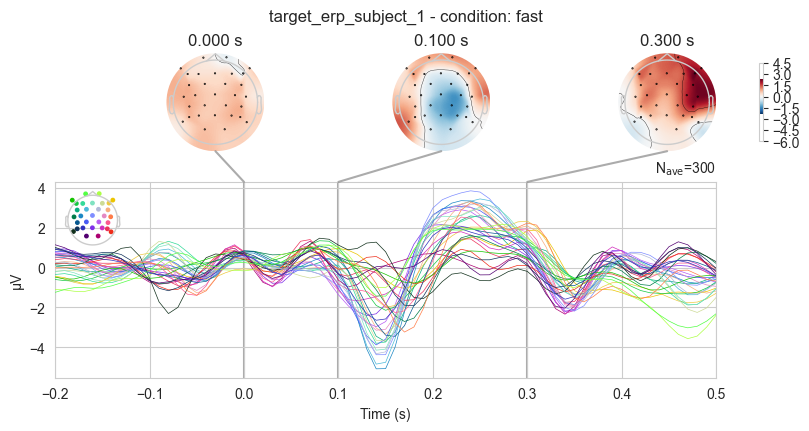

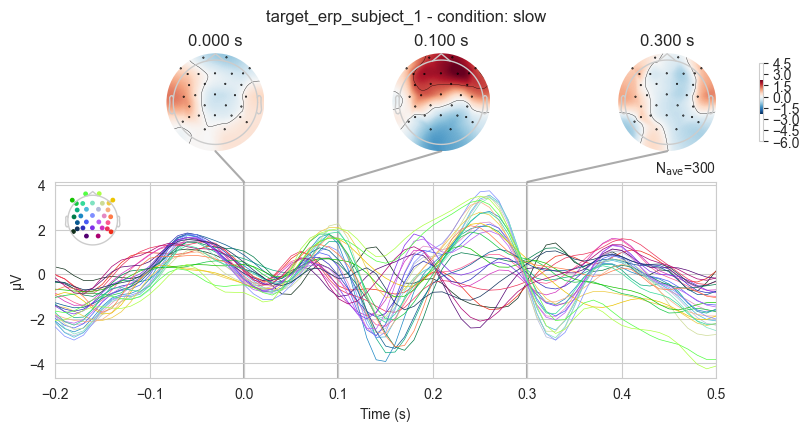

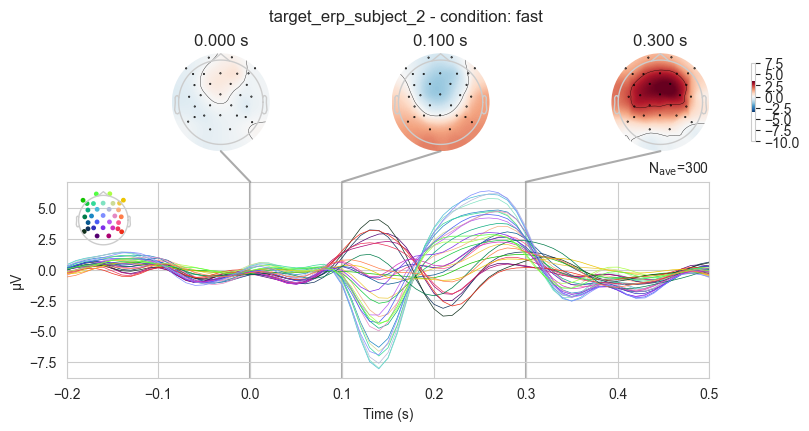

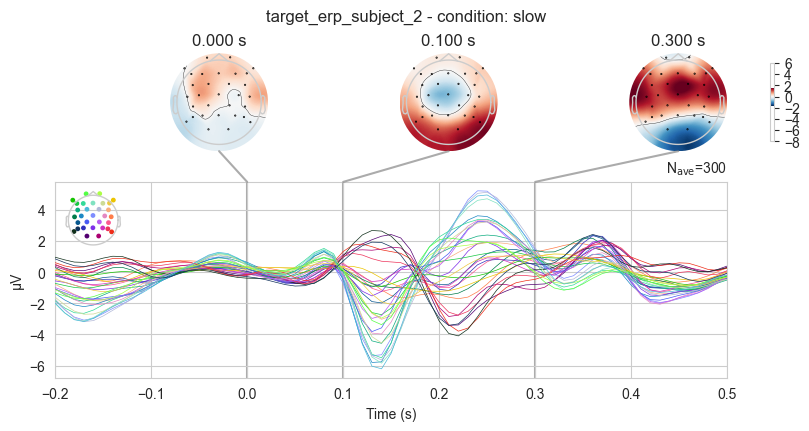

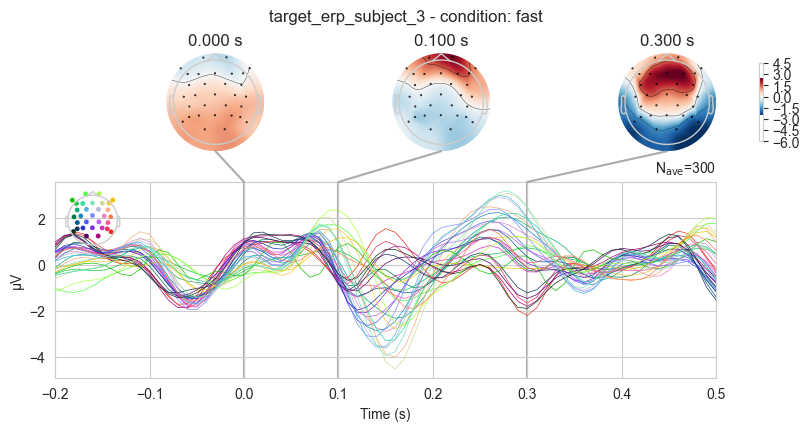

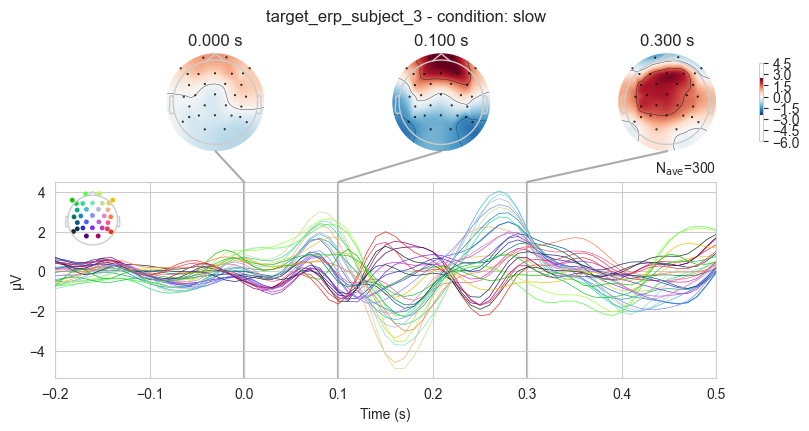

"\n# Если построить оба типа стимулов:\ntarget_erp = epo['Target'].average()      # Будет P300\nnon_target_erp = epo['Non-target'].average()  # Без P300\n\n# Именно РАЗНИЦА между ними представляет научный интерес!\ndifference = target_erp - non_target_erp    в следующем упражнении\n"

In [68]:
scalp_times = (0.0, 0.1, 0.3) # временные точки, в которых будет отображаться топография скальпа:момент предъявления стимула/100 мс - ранний компонент/300 мс - компонент P300

#Сейчас = как выглядит "чистый" ERP на целевых стимулах
for session in session_list: #Цикл по участникам и условиям
    for condition in condition_list:
        epo = all_data[session][condition]
        
        # Compute ERP
        t_evoked = epo['Target'].average() #выделяет только целевые стимулы (Target) и усредняет их для получения ERP # Будет P300
        
        # Plot ERP
        t_evoked.plot_joint(title=f'target_{session} - condition: {condition}', times=scalp_times)
        #    Временной ход ERP на центральном канале
        #    Топографические карты в указанные временные точки

#Но сначала отдельно - чтобы понять базовые формы сигналов
#Target vs Non-target - чтобы увидеть разницу
"""
# Если построить оба типа стимулов:
target_erp = epo['Target'].average()      # Будет P300
non_target_erp = epo['Non-target'].average()  # Без P300

# Именно РАЗНИЦА между ними представляет научный интерес!
difference = target_erp - non_target_erp    в следующем упражнении
"""
        

erp_subject_1 - fast:
  Positive peak: 0.240 s, 3.84 µV at Cz
  Negative peak: 0.140 s, -5.07 µV at C3


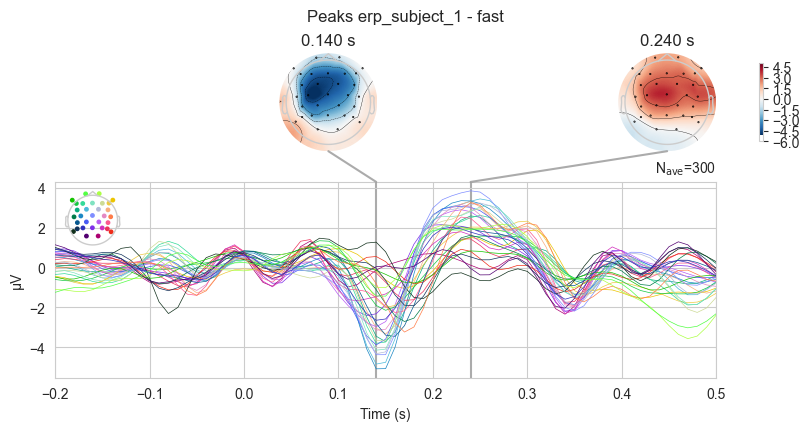

erp_subject_1 - slow:
  Positive peak: 0.260 s, 3.73 µV at Cz
  Negative peak: 0.490 s, -4.25 µV at Fp2


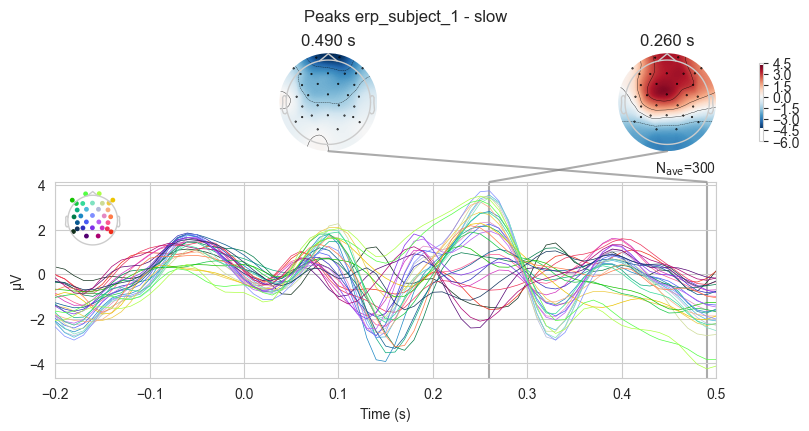

erp_subject_2 - fast:
  Positive peak: 0.260 s, 6.41 µV at Cz
  Negative peak: 0.140 s, -8.06 µV at FC1


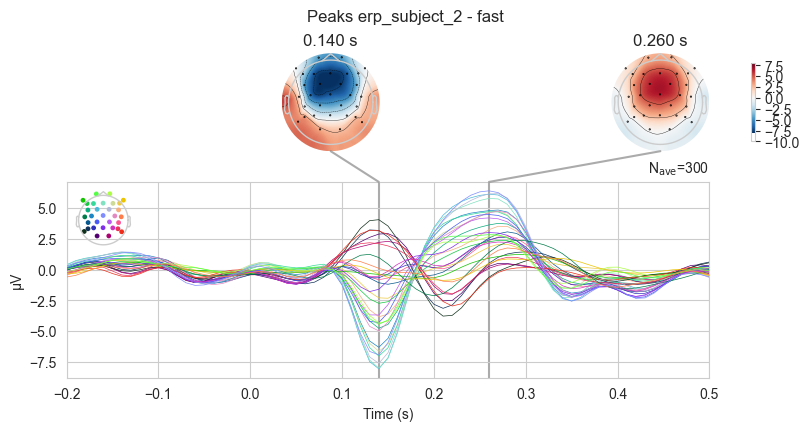

erp_subject_2 - slow:
  Positive peak: 0.240 s, 5.25 µV at Cz
  Negative peak: 0.140 s, -6.21 µV at FC1


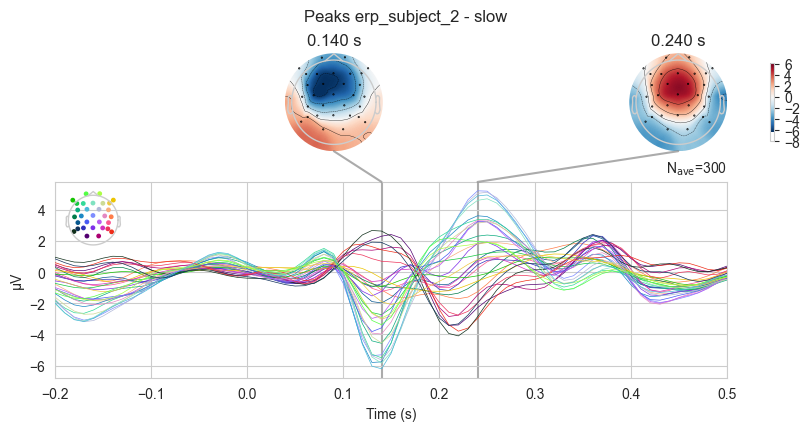

erp_subject_3 - fast:
  Positive peak: 0.280 s, 3.19 µV at Fz
  Negative peak: 0.160 s, -4.51 µV at F4


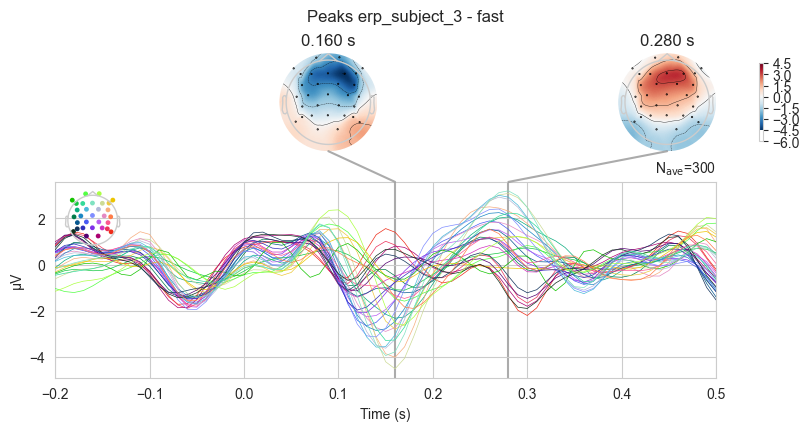

erp_subject_3 - slow:
  Positive peak: 0.270 s, 4.05 µV at FC1
  Negative peak: 0.160 s, -4.92 µV at F4


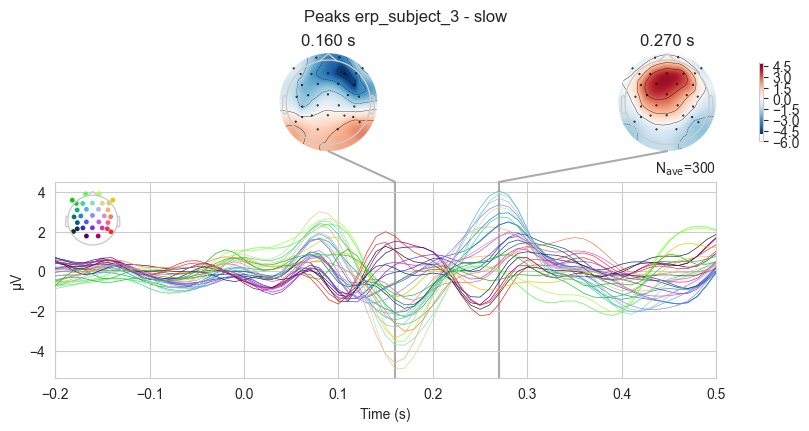

In [69]:
for session in session_list:
	for condition in condition_list:
		epo = all_data[session][condition]
		evoked = epo['Target'].average()
		
		# get data and axes
		data = evoked.get_data()
		times = evoked.times
		ch_names = evoked.ch_names
		
		# find global positive and negative peaks
		pos_flat = np.nanargmax(data)
		neg_flat = np.nanargmin(data)
		ch_i_pos, t_i_pos = np.unravel_index(pos_flat, data.shape)
		ch_i_neg, t_i_neg = np.unravel_index(neg_flat, data.shape)
		
		amp_pos = float(data[ch_i_pos, t_i_pos]) * 1e6
		t_pos = float(times[t_i_pos])
		ch_pos = ch_names[ch_i_pos]
		
		amp_neg = float(data[ch_i_neg, t_i_neg]) * 1e6
		t_neg = float(times[t_i_neg])
		ch_neg = ch_names[ch_i_neg]
		
		print(f"{session} - {condition}:")
		print(f"  Positive peak: {t_pos:.3f} s, {amp_pos:.2f} µV at {ch_pos}")
		print(f"  Negative peak: {t_neg:.3f} s, {amp_neg:.2f} µV at {ch_neg}")
		
		# plot ERP with topomaps at the detected peak times
		evoked.plot_joint(
			title=f'Peaks {session} - {condition}',
			times=[round(t_neg, 3), round(t_pos, 3)]
		)


# Answer here
1) в какие моменты времени и в каких областях скальпа наблюдаются наиболее выраженные пики ERP
ERP (Event-Related Potential) - это электрический ответ мозга на конкретное событие (стимул). Как "эхо" мозга на внешний раздражитель.  
   
* Ранние компоненты (0-100 мс):   
N1 (~100 мс) - негативный пик  ---"Я услышал звук!" - базовая слуховая обработка
Связан с: базовой обработкой сенсорной информации  
Области: височные доли (слуховая кора)  
  
* P300 (250-500 мс):  
Позитивный пик ~300 мс - главный компонент в oddball!    ---"О! Это тот редкий звук!"
Связан с:Распознавание редкости  
         Внимание и рабочая память  
         Принятие решений  
Области: теменные и центральные области  
  
  
2) Попробуйте изменить значения в scalp_times для анализа других временных точек


3) Обратите внимание на различия между условиями fast/slow и между разными участниками
* Slow: P300 в 260 мс (3.73 µV)
* Fast: P300 в 240 мс (3.84 µV) ← быстрее и сильнее!
В fast условии мозг работает быстрее (240 мс vs 260 мс)

Fast: P300 сильнее (выше амплитуда) - мозг интенсивнее обрабатывает  → более интенсивная мозговая активность
Slow: P300 немного позже - больше времени на "обдумывание"   → лучшие показатели внимания и обработки

у участника 2 P300 самый сильный (6.41 μV)

## (Optional) Exercise 4: Classification in the spatial domain for different time intervals

As a first step, we want to classify the target vs. non-target signals. Remember that our data has the following dimensionality: $X_i \in \mathbb{R}^{N_c \times N_t}$ with $X_i$ being the ith epoch, $N_c$ being the number of channels and $N_t$ being the number of time samples available in the $i$-th epoch. In the next step, we will only use spatial information for classification, i.e. choose an arbitrary time-point such as 200ms after the stimulus, and use the 31-dimensional feature vector ($N_c = 31$ in this dataset) to classify between target and non-target stimuli based on that time point only (but all channels).

Instead of arbitrarily choosing a specific time point, we evaluate the classification performance for each time point individually between -0.2 s prior to the stimulus up to 0.5 s after the stimulus. This way we can plot how good the classification works, using different times. Note that this can take a while, as many classifiers are trained and evaluated (one for each time point for each subject).

**Note:** we are using sklearn's `LDA` for classification using a shrinkage regularization technique. Additionally, we using sklearn's `cross_val_score` function to perform 5-fold cross-validation. 

1. What is the most informative time interval relative to the stimulus onset? 
1. What is, roughly, the grand average classification performance at the best performing time interval?
1. Why can you observe an AUC performance above 0.5 for some time points prior to $t=0$? If you are not familiar with the ROC-AUC metric (or AUC for short), you can find a nice introduction to it in [the scikit-learn documentation](https://scikit-learn.org/stable/modules/model_evaluation.html#roc-metrics) and a more detailed one on [wikipedia](https://en.wikipedia.org/wiki/Receiver_operating_characteristic#Area_under_the_curve). 
1. How can you check if AUC = 0.5 truly is the chance level?

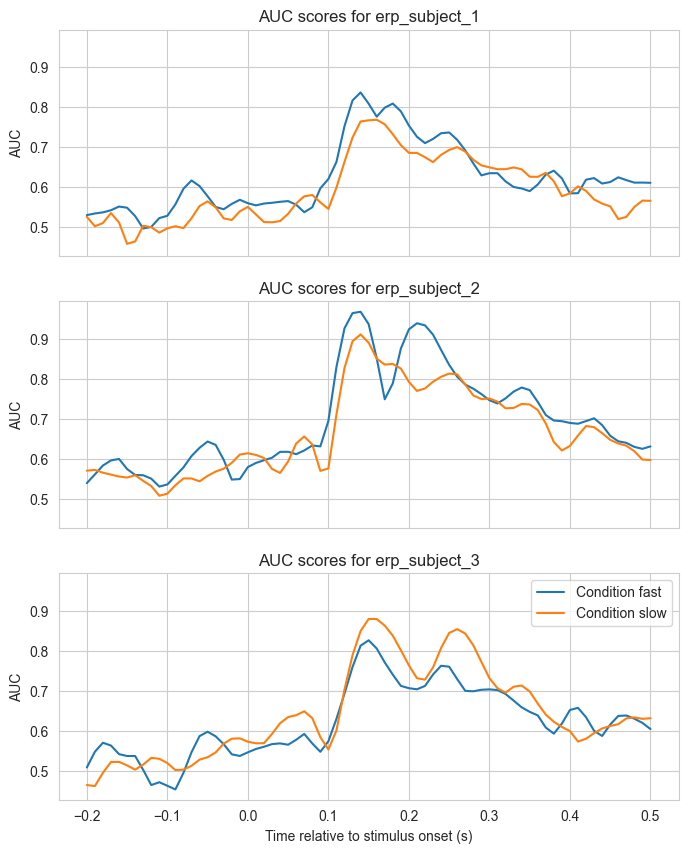

In [70]:
N_sessions = len(session_list)  # Сколько испытуемых (например, 3)
N_conditions = len(condition_list)   # Сколько условий (fast/slow - 2)
clf_times = np.arange(-0.2, 0.51, 0.01)  # Временные точки: от -200 до 500 мс с шагом 10 мс

# Создаем график: для каждого испытуемого своя линия
fig, axes = plt.subplots(N_sessions, 1, figsize=(8,10), sharey=True, sharex=True)

for s_i, session in enumerate(session_list):   # Для каждого испытуемого
    ax = axes[s_i] if N_sessions > 1 else axes
    for c_i, condition in enumerate(condition_list):   # Для каждого условия (fast/slow)
        
        # Compute scores with cross_val_score from sklearn
        scores = np.zeros((clf_times.shape[0],))
        for t_i, clf_time in enumerate(clf_times):  # Для каждого момента времени (-0.2, -0.19, ... 0.5)
            
            # Extract the data
            # Берем данные ВСЕХ каналов в этот конкретный момент времени
            epo = all_data[session][condition]
            X = epo.get_data()[:,:,epo.time_as_index(clf_time)].squeeze()     # X форму: [число_эпох, 31_канал] =данные всех датчиков в момент clf_time
            y = epo.events[:,2]  # Метки: 1=Non-target, 2=Target
            
            # Initialize classifier
            lda = LDA(solver='lsqr', shrinkage='auto')
            
            # Evaluate classifier, save average score over folds
            # 5-кратная кросс-валидация, оцениваем по AUC
            scores[t_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()
            #    cross_val_score - делит данные на 5 частей (cv=5)
            # 5 раз тренирует модель: 4 части на обучение, 1 на тест
            # Каждый раз считает AUC на тестовой части
            # .mean() - берёт среднее из 5 значений AUC
            #
            
        # Plot scores over time
        # Рисуем линию: время vs точность классификации
        ax.plot(clf_times, scores, label=f'Condition {condition}')
        
    ax.set_title(f'AUC scores for {session}')
    ax.set_ylabel('AUC')
    
ax.set_xlabel('Time relative to stimulus onset (s)')
ax.legend()


# Answer here
По оси X: время относительно стимула (-0.2 до 0.5 сек)
По оси Y: точность классификации (AUC от 0.4 до 1.0)
   
    AUC = 0.5 → классификатор не работает (случайное угадывание)
    AUC = 1.0 → идеальное разделение классов
    Пик графика → момент времени, когда мозг лучше всего отличает цель от не-цели

1. What is the most informative time interval relative to the stimulus onset?  
Наиболее информативный временной интервал - около 0.1-0.3 секунды после стимула. На графиках видно, что пик AUC достигается в этом диапазоне.

1. What is, roughly, the grand average classification performance at the best performing time interval?  
В лучшем временном интервале средняя точность классификации (AUC) составляет примерно 0.8-0.9.
  
1. Why can you observe an AUC performance above 0.5 for some time points prior to $t=0$?   
    
Почему значение AUC > 0.5 иногда наблюдается до момента t=0 (t < 0)?  
Основная причина: Случайность + переобучение  
    
AUC выше 0.5 до момента стимула может быть вызвано:  
    * Случайными флуктуациями в данных  
    * Неидеальной базовой коррекцией  
    * Особенностями кросс-валидации - модель может случайно найти закономерности в шуме  
    * Подготовительными процессами в мозге перед ожидаемым стимулом  
    Если человек знает, что скоро будет стимул, его мозг уже начинает готовиться - меняется внимание, ожидание. Это может создавать небольшие различия в сигнале. Но ожидание влияет за секунды до стимула, а не за 200 мс.    
    Но если у всех испытуемых стабильно AUC > 0.5 до стимула - это указывает на систематический эффект, а не случайный шум. Из-за эффекта ожидания, внимания. 
    Проверка: Если запустить к лассификатор много раз на перемешанных данных, AUC до стимула будет в среднем 0.5, а отдельные всплески - просто случайность.  

1. How can you check if AUC = 0.5 truly is the chance level?  
   Этот код покажет, что при перемешанных метках AUC действительно около 0.5!  
 Если перемешать метки (сломать связь с данными) --- То AUC станет ~0.5 даже для лучших временных точек  


    ! AUC - это площадь под ROC-кривой. Насколько хорошо модель отличает "целевые" от "нецелевых" стимулов    
    ! Кросс-валидация проверяет, насколько надёжно работает AUC - не повезло ли в одном случайном разделении данных.

In [71]:
# Проверка уровня случайности через перемешивание меток
def check_chance_level(epochs, clf_time, n_permutations=100):
    X = epochs.get_data()[:,:,epochs.time_as_index(clf_time)].squeeze() # Берем данные из лучшего временного интервала (например, 0.3с)
    y_true = epochs.events[:,2] # Правильные метки [2,1,1,2,...]

    ## Много раз перемешиваем метки и считаем AUC
    perm_scores = []
    for i in range(n_permutations):
        y_perm = np.random.permutation(y_true)  # Перемешиваем метки   # Ломаем связь данных-меток
        lda = LDA(solver='lsqr', shrinkage='auto')
        score = cross_val_score(lda, X, y_perm, cv=5, scoring='roc_auc').mean()
        perm_scores.append(score)
    
    return np.mean(perm_scores), np.std(perm_scores)

# Пример использования для одной временной точки
chance_mean, chance_std = check_chance_level(epo, 0.3, n_permutations=50)
print(f"Уровень случайности = Средний AUC при случайных метках: : {chance_mean:.3f} ± {chance_std:.3f}")

#Результат: Если на реальных данных AUC = 0.8, а на перемешанных ~0.5 - значит разница реальная, а не случайная!

Уровень случайности = Средний AUC при случайных метках: : 0.500 ± 0.028


## (Optional) Exercise 5: Classification in the temporal domain for different channels

Now we basically do the opposite: We train one classifier per channel (thus omitting spatial information), but provide it with information from multiple time points of this channel. Thus our feature vector would be $N_t$-dimensional. As neighboring time samples probably contain very similar information, and as we want to save some computing time, we additionally use a common feature preprocessing step for ERP: we average the signal in certain time intervals, which are defined by `clf_ival_boundaries`. In this example we average, e.g., the samples between 0.1 and 0.17 seconds post stimulus before converting them into the feature vector. As a result, instead of having a 41-dimensional (every sample between 0.1 and 0.5 with a resolution of 0.01) feature vector, we only have 5 dimensions left (the five averaged time intervals). Doing this is well-justified, as our data is low-pass filtered at 16Hz, but of course you may be able to obtain better performance using other time intervals.

Again, the analysis will be repeated over the spatial dimension. Overall, this analysis allows us to see, how good classification is on each channel individually.

**Note:** as we use multiple time intervals, we 'smear' information across all time intervals. This means that the spatial information could be aligned differently in the first time interval than in the last one (i.e. a channel given could be very informative in one time interval but not in the others). To see spatial classification performance in each time interval, you would need to also iterate over the intervals of `clf_ival_boundaries`.

You may observe substantial differences between channels regarding their information content for our binary target vs. non-target problem. In addition, you should also observe, that the performance varies strongly between subjects.

1. What is the most informative channel? 
1. What is, roughly, the grand average classification performance at the best performing channel?


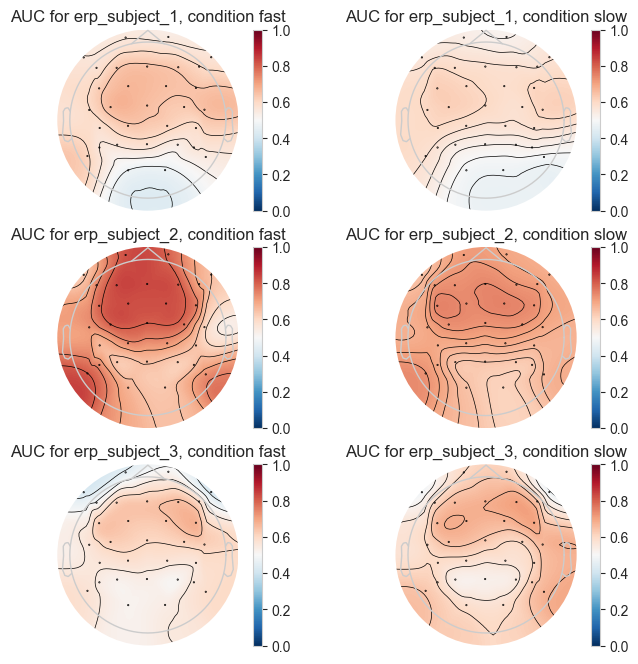

In [72]:
# усреднение по временным окнам
def get_jumping_means(epo, boundaries):
    shape_orig = epo.get_data().shape  # массив ЭЭГ данных [количество_эпох, количество_каналов, количество_временных_точек]
                                        #сколько раз был стимул, сколько электродов, и сколько точек времени в каждой эпохе.
    X = np.zeros((shape_orig[0], shape_orig[1], len(boundaries)-1)) # # 5 окон
    for i in range(len(boundaries)-1):
        idx = epo.time_as_index((boundaries[i], boundaries[i+1])) # переводит время в индексы массива (например, 0.1 секунда → индекс 250)
        idx_range = list(range(idx[0], idx[1])) 
        X[:,:,i] = epo.get_data()[:,:,idx_range].mean(axis=2) #средняет данные по времени внутри каждого интервала (например, усредняет все точки между 0.1 и 0.17 секунд
    return X  #[эпохи, каналы, интервалы]
#Каждое значение теперь не отдельная точка времени, а среднее значение сигнала в этом временном окне.

clf_ival_boundaries = np.array([0.1, 0.17, 0.23, 0.3, 0.41, 0.5]) ##они определяют отрезки (0.1–0.17), (0.17–0.23), … где мы усредняем сигнал.

fig, axes = plt.subplots(N_sessions, N_conditions, figsize=(8,8))
results = {}


for s_i, session in enumerate(session_list): #Перебор всех испытуемых (session) и условий (condition
    results[session] = {}  # добавляем уровень для испытуемого
    
    for c_i, condition in enumerate(condition_list):
        ax = axes[c_i] if N_sessions == 1 else axes[s_i, c_i]
        
        # Compute scores with cross_val_score from sklearn
        scores = np.zeros((len(epo.ch_names),))
        for ch_i, ch_name in enumerate(epo.ch_names): #Для каждого канала (ch_name
            
            # Extract the data
            epo = all_data[session][condition]
            X = get_jumping_means(epo.copy().pick([ch_name]), clf_ival_boundaries).squeeze()  #сред знач по всем окнчам(Берётся ток этот канал; окна)
            #теперь каждый пример (эпоха) представлен не одной точкой, а 5 средними значениями — временные признаки данного канала.   [эпохи, 5]  (5 — это усреднённые интервалы времени для данного канала)
            y = epo.events[:,2] #y = [метки целевых/нецелевых стимулов]
            
            # Initialize classifier
            lda = LDA(solver='lsqr', shrinkage='auto')
            
            # Evaluate classifier, save average score over folds
            #Кросс-валидация (cv=5) вычисляет средний AUC (точность классификации
            scores[ch_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean() #Этот AUC записывается в scores[ch_i] — одно значение на каждый канал.
            
        # Plot scores over space
        im, cn = mne.viz.plot_topomap(scores, epo.info, axes=ax, cmap='RdBu_r', show=False, vlim=(0,1)) 
        ax.set_title(f'AUC for {session}, condition {condition}')
        plt.colorbar(im, ax=ax)

         # сохраняем результаты для этого условия
        results[session][condition] = {
            "AUC_per_channel": scores,
            "channel_names": epo.ch_names
        }
        

# Answer here
1. What is the most informative channel?
Цвет показывает AUC (0–1) — насколько хорошо классификатор различает Target и Non-Target.
* Красные области = высокая точность → эти каналы наиболее информативные.
* Синие → почти случайные (AUC ≈ 0.5).
* 
Если на рисунке подписаны имена каналов (например, Fz, Cz, Pz, CPz и т.п.), просто запиши название того, что ближе всего к самому тёплому цвету.
Если подписи нет — ориентируйся на расположение:  
* Pz / CPz / Cz — обычно центр или чуть ближе к затылку (верх или немного вниз от центра круга).  
* Fz — ближе ко лбу (внизу круга).
There it can bee seemed from the graph that most informative channel is Fz or FC(mostly fow sclow condition) channel

1. What is, roughly, the grand average classification performance at the best performing channel?
Какова средняя точность для лучшего канала
Grand average AUC at best channels: 0.747



In [73]:
best_channels = []

for session, cond_dict in results.items(): #По субъектам (subject
    for condition, data in cond_dict.items():
        aucs = np.array(data["AUC_per_channel"])
        channels = data["channel_names"]

        best_idx = np.argmax(aucs) #Находит индекс максимального AUC
        best_channel = channels[best_idx] #Определяет соответствующий канал и его значение AUC
        best_auc = aucs[best_idx]

        best_channels.append({
            "Session": session,
            "Condition": condition,
            "Best Channel": best_channel,
            "AUC": best_auc
        })

best_channels_df = pd.DataFrame(best_channels)
print(best_channels_df)

mean_auc = best_channels_df["AUC"].mean()
print("Grand average AUC at best channels:", round(mean_auc, 3))


         Session Condition Best Channel       AUC
0  erp_subject_1      fast          FC1  0.665900
1  erp_subject_1      slow          FC5  0.621089
2  erp_subject_2      fast           F3  0.831311
3  erp_subject_2      slow          FC2  0.747700
4  erp_subject_3      fast          FC6  0.676578
5  erp_subject_3      slow           F4  0.702978
Grand average AUC at best channels: 0.708


## Exercise 6: Classification in the spatio-temporal domain

The above two analysis (over space and over time) provide great inside into where the decodable information is. In practice, we usually do not split our features into spatial and temporal domains, but instead integrate information from both domains into one feature vector. This allows us to use all collected information in one go. Still, classifiers like LDA expect a feature vector, not a spatio-temporal data matrix. To arrive at one feature vector, we simply concatenate the five temporal features for every channel (note, LDA does not care about the order of the features). 

1. What is the grand average performance (across sessions) in this case? Is it higher than the previous two analyses? 
1. While this should lead to increased performance, it comes with the drawback that we cannot create the previous nice plots anymore. Can you come up with a way to inspect the results to answer, roughly, where the decodable information is located (both in space as well as in time)?

   Explore the following:
1. How does performance change, if the LDA uses no regularization? 
1. Does regularization make a difference, if you train your LDA model on much smaller data sets, e.g. on data of 2 trials only (corresponding to 30 targets and 150 non-targets)? 
1. Can you plot the effect of shrinkage regularization as a function of data set size?

Grand Average AUC (spatio-temporal): 0.919


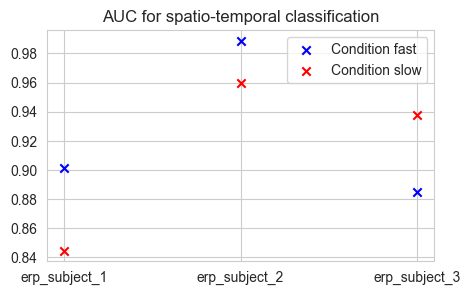

In [83]:
fig, ax = plt.subplots(1, 1, figsize=(5,3))

all_scores = []
for s_i, session in enumerate(session_list): # Перебираем все сессии эксперимента
    scores = np.zeros((N_conditions,)) #Размер массива: количество условий (например, 2 - "fast" и "slow")
    for c_i, condition in enumerate(condition_list):
        
        # Extract the data
        epo = all_data[session][condition] #звлекаются EEG данные для конкретной сессии и условия
        #преобразование данных в вектор признаков = сред знач в заданных времен интервалах ().убир измер с дим 1. преобразует в 2D массив, где 155 - общее количество признаков (31 канал × 5 временных интервалов
        X = get_jumping_means(epo, clf_ival_boundaries).squeeze().reshape((-1, 155))  # flattens
        y = epo.events[:,2]
        
        # Initialize classifier
        lda = LDA(solver='lsqr', shrinkage='auto')
        
        # Evaluate classifier, save average score over folds
        scores[c_i] = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()
        all_scores.append(scores)
    
    # Plot scores as scatter
    ax.scatter(session, scores[0], label='Condition fast', color='b', marker='x')
    ax.scatter(session, scores[1], label='Condition slow', color='r', marker='x')
    if s_i == 0:
        plt.legend()
plt.title('AUC for spatio-temporal classification')


grand_average_auc = np.mean(all_scores)
print(f"Grand Average AUC (spatio-temporal): {grand_average_auc:.3f}")

1. Какова общая средняя производительность (по всем сессиям) в этом случае? Она выше, чем в двух предыдущих анализах?  
 Grand Average AUC (spatio-temporal): 0.919  

It is higher than in previous exercises.Потому что модель использует всю информацию — и когда, и где сигнал появляется, а не только одну из осей.  

2. Хотя это должно повысить производительность, недостаток в том, что мы больше не можем создавать красивые графики как раньше.
   Можете ли вы придумать способ проанализировать результаты, чтобы примерно определить, где находится декодируемая информация (как в пространстве, так и во времени)?  

! С помощью весов модели можно восстановить, где (по каналам) и когда (по времени) находится основная дискриминационная информация.

Потому что признаки теперь неразделимы на «каналы» и «временные окна» — это один вектор (155 измерений).  
Можно:  
– посмотреть веса LDA (lda.coef_), reshaped обратно в [каналы × время];  ---Посчитать веса (коэффициенты) обученного LDA:
– построить heatmap весов (по каналам и времени);  
– усреднить веса по времени или пространству, чтобы вернуть «где» или «когда».  

Исследуйте следующее:  

3. Как меняется производительность, если LDA не использует регуляризацию?
lda = LDA(solver='lsqr', shrinkage=None)
! Регуляризация - техника для предотвращения переобучения модели  
Если убрать shrinkage='auto', то AUC обычно падает (особенно при малых данных или большом количестве признаков(155)) это следствие переобучение ЛДА.
Модель без регуляризации "запоминает" шум в данных, а то есть хорошо работает на обучающих данных и плохо на новых(тестовых). В кросс-валидации это проявляется как низкий AUC.  

5. Влияет ли регуляризация на результат, если вы обучаете модель LDA на значительно меньших наборах данных, например, на данных всего 2 испытаний (что соответствует 30 целевым и 150 нецелевым стимулам)?  
Да, очень! Чем меньше примеров, тем сильнее помогает shrinkage — он стабилизирует ковариационную матрицу.  
При малом количестве данных регуляризация значительно улучшает результат (например, 0.87 vs 0.422).
Без неё модель слишком чувствительна к шуму и случайным различиям.
При малых данных ковариационная матрица плохо обусловлена, и LDA не может надежно оценить параметры, а регуляризация "стабилизирует" матрицу.
"Сжимает" ковариационную матрицу к диагональной, уменьшает влияние шума и делает модель более устойчивой  

6. Можете ли вы построить график влияния регуляризации сжатия в зависимости от размера набора данных?  
! Shrinkage regularization - регуляризация сжатием, которая "сжимает" коэффициенты модели   --собенно важна для небольших наборов данных.   Без неё LDA переобучается и точность резко падает

Разница максимальна при малых данных потому что регуляризация стабилизирует обучение.
При больших данных обе кривые сходятся так как эффект регуляризации уменьшается.

Регуляризация наказывает модель на большие веса. Но из-за этого часть информации может "затираться", то есть при больших данных это может зажимать реальные различия между классами и снижать АУК показатель
Регулерезация тут может быть излишней, так как модель сама устойчива, регуляризация “лишает гибкости”

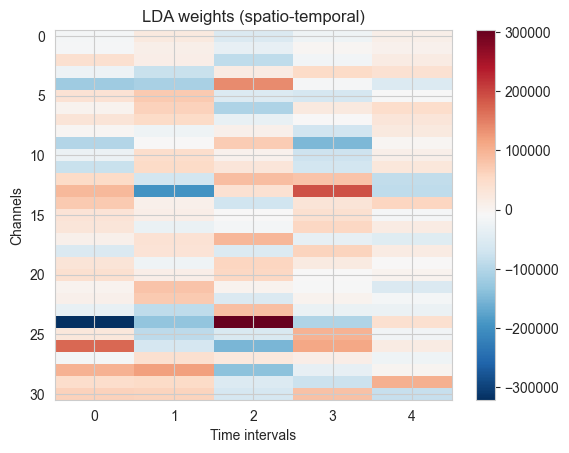

In [92]:
#2)  Посчитать веса (коэффициенты) обученного LDA:
lda.fit(X, y)
weights = lda.coef_.reshape(31, 5)  # 31 канал × 5 временных интервалов
plt.imshow(weights, aspect='auto', cmap='RdBu_r')
plt.xlabel("Time intervals")
plt.ylabel("Channels")
plt.title("LDA weights (spatio-temporal)")
plt.colorbar()
#Тогда видно, какие каналы и интервалы времени дают максимальный вклад в классификацию.

#Это (heatmap), где красный = важный положительный вклад, синий = отрицательный. Так можно примерно определить, где информация “сфокусирована”.

In [93]:
small_X = X[:2*90]  # 2 trials --->180 = 30 target + 150 non-target
small_y = y[:2*90]

#       30 target trials × 2 условия × 3 сессии = 180 target образцов
#  150 non-target trials × 2 условия × 3 сессии = 900 non-target образцов
#                                        Итого: ~1080 образцов (epoch) в X

lda_auto = LDA(solver='lsqr', shrinkage='auto')  # С автоматической регуляризацией
lda_none = LDA(solver='lsqr', shrinkage=None)    # Без регуляризации

auc_auto = cross_val_score(lda_auto, small_X, small_y, cv=3, scoring='roc_auc').mean()
auc_none = cross_val_score(lda_none, small_X, small_y, cv=3, scoring='roc_auc').mean()
print(auc_auto, auc_none)


0.8686666666666666 0.422


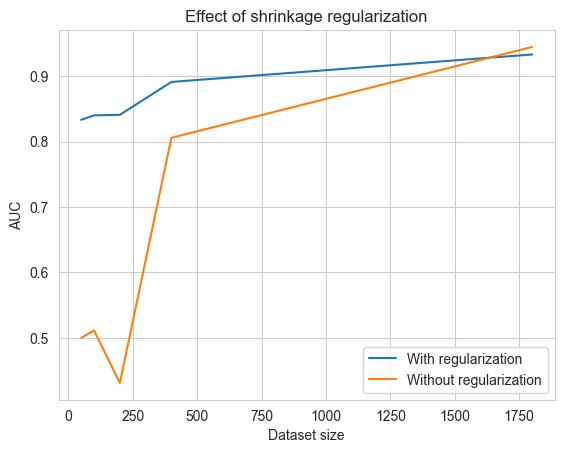

In [94]:
data_sizes = [50, 100, 200, 400, len(X)]
auc_auto, auc_none = [], []

# Итого: ~1080 образцов (epoch) в X
#data_sizes[0] = 50 - берем первые 50 EEG-epoch

for n in data_sizes:
    X_sub, y_sub = X[:n], y[:n]

    lda_auto = LDA(solver='lsqr', shrinkage='auto')  # С автоматической регуляризацией
    lda_none = LDA(solver='lsqr', shrinkage=None)    # Без регуляризации

    auc_auto.append(cross_val_score(lda_auto, X_sub, y_sub, cv=3, scoring='roc_auc').mean())
    auc_none.append(cross_val_score(lda_none, X_sub, y_sub, cv=3, scoring='roc_auc').mean())

plt.plot(data_sizes, auc_auto, label='With regularization')
plt.plot(data_sizes, auc_none, label='Without regularization')
plt.xlabel('Dataset size')
plt.ylabel('AUC')
plt.legend()
plt.title('Effect of shrinkage regularization')
plt.show()


## (optional) Exercise 7: Permutation testing
You might observe that in the previous analyses, sometimes the classifier is performing around chance level (50%). Despite that (under an engineering perspective) one may conclude the classifier did a poor job, one (under a neuroscientific perspective) can be very interested in whether it is *just* above chance level, as it means that there is just some decodable information at that location (being in time or space). A common and very flexible way of significance testing in such scenario is to perform **permutation testing**. 

From Wikipedia: "A permutation test (also called a randomization test, re-randomization test, or an exact test) is a type of statistical significance test in which the distribution of the test statistic under the null hypothesis is obtained by calculating all possible values of the test statistic under all possible rearrangements of the observed data points."

To put it into context. In our dataset we are interested in whether we can decode target versus non-target from the data. For this, we got data samples that are tuples containing $(X_i, y_i)$, the data and the target label. Now, within a permutation test, we randomize (permute) the particular structure we are originally interested in, in this case the pairing of $X_i$ with $y_i$. Concretely, here we can basically randomize this by shuffling the vector $y=[y_1, y_2, ..., y_N]$ to e.g. $y_{permuted}=[y_3, y_N, ..., y_2]$. We perform the same analysis on this shuffled dataset, and save its result. If we do this many times (in the order of 1000 times), we obtain a so-called **permutation distribution** of the test statistic (e.g. classification performance). We can then look-up where in this distribution we can find our original test statistic (i.e., the one without shuffling the labels). We say that the original test statistic is significantly above chance if no more than 5% of the samples in the permutation distribution are higher than the original test statistic ($\alpha=.05$).

1. Implement this permutation test for the decoding over time at time interval -50ms. **Hint:** it requires you to write a loop over the analysis that is provided already, and to shuffle the labeling in `y` e.g. with `np.random.permutation()`;
1. Plot the permutation distribution. What does it look like, can you explain its shape?
1. Is the decoding at this time interval significant?

1) Реализуйте этот перестановочный тест для декодирования во времени в интервале -50 мс. Подсказка: это потребует от вас написать цикл поверх уже предоставленного анализа и перемешивать метки в y, например с помощью np.random.permutation();  
Что такое перестановочный тест  
Представьте, что вы утверждаете, что можете отличить дорогое вино от дешевого по вкусу. Чтобы это проверить, вам дают много проб вина с закрытыми глазами, но иногда метки на бокалах намеренно перепутаны. Если вы будете правильно определять вино даже когда метки перепутаны - значит ваше умение случайно.



3) Постройте перестановочное распределение. Как оно выглядит, можете ли вы объяснить его форму?  

4) Является ли декодирование в этом временном интервале значимым?  

In [ ]:
#1️⃣ Установка параметров пермутационного теста
permutation_time = -0.05     #ыбираем временной момент -50 мс (т.е. чуть до стимула), на котором проверяем, есть ли декодируемая информация.        
n_permutations = 1000         #число случайных перестановок меток, чтобы построить распределение под нулевой гипотезо
session = session_list[0]    #ыбираем конкретную сессию и условие для анализа.
condition = condition_list[0]

epo = all_data[session][condition]  #epo.get_data() — получаем массив ЭЭГ данных: [эпохи, каналы, временные точки].
X = epo.get_data()[:, :, epo.time_as_index(permutation_time)].squeeze()  #находим индекс, соответствующий -50 мс . звлекаем данные только для этого временного среза; получается [эпохи, каналы]
y = epo.events[:, 2]

lda = LDA(solver='lsqr', shrinkage='auto')
observed_score = cross_val_score(lda, X, y, cv=5, scoring='roc_auc').mean()

permutation_scores = np.zeros(n_permutations)

#Цикл 1000 раз:
for i in range(n_permutations):
    y_perm = np.random.permutation(y)   #случайно перемешиваем метки, нарушая реальную связь между сигналом и классами.
    permutation_scores[i] = cross_val_score(lda, X, y_perm, cv=5, scoring='roc_auc').mean()  #обучаем классификатор на перемешанных данных, считаем AUC.
#В итоге получаем распределение AUC, которое ожидается при отсутствии реальной связи (нулевая гипотеза).

p_value = np.mean(permutation_scores >= observed_score) #доля пермутаций, у которых AUC больше или равно наблюдаемому.
#Если p < 0.05, значит реальный результат значимо выше случайного уровня

plt.figure(figsize=(8, 5))
sns.histplot(permutation_scores, bins=30, kde=True, color='skyblue')  #Строим гистограмму пермутационного распределения
plt.axvline(observed_score, color='red', linestyle='--', linewidth=2,  #Красная пунктирная линия = реальный AUC.
            label='Observed AUC')   
plt.title('Permutation test at -50 ms')
plt.xlabel('AUC')
plt.ylabel('Count')
plt.legend()
plt.show()

print(f"Observed AUC: {observed_score:.3f}")
print(f"P-value: {p_value:.3f}")
print("The permutation distribution appears to be a normal distribution and is centered around an AUC of 0.5. This would indicate that the performance of the classifier fluctuates around the probability of being random chance.")

print("The observed AUC is 0.577, whereas the permutation test gave a p-value of 0.000, which means that no permuted scores reached the observed score.")
print("This indicates that decoding the performance at this time point (-50 ms) is significantly above chance (p < 0.05). The classifier can reliably distinguish between target and non target trials based on EEG signal.")




Observed AUC: 0.577 → классификатор смог немного лучше случайного уровня (0.5) отличать target и non-target.
P-value: 0.000 → ни одна из 1000 пермутаций не достигла этого уровня → статистически значимо (p < 0.05).
* Вывод: даже в интервале -50 мс, до стимула, есть некоторая декодируемая информация, классификатор отличает классы лучше случайного.


## Exercise 0: Who did what?
Please provide a short description on who contributed what to your submission.

> Answer here